In [1]:


# 1. Import all libraries at once
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import itertools
from zipfile import ZipFile
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [4]:
from google.colab import drive
drive.mount('/content/drive')
zip_path = "/content/drive/MyDrive/dataset.zip"
extract_path = "/content/dataset"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting!")
os.listdir("/content/dataset")

Mounted at /content/drive
Done extracting!


['FIRE-SMOKE-DATASET']

In [18]:
# 3. Configuration and constants
IMG_SIZE = 64  # Keeping original size for faster training
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 3
DATA_DIR = '/content/dataset/FIRE-SMOKE-DATASET'

# Verify dataset structure
print("Checking dataset structure...")
for split in ['Train', 'Test']:
    path = f'{DATA_DIR}/{split}'
    if os.path.exists(path):
        classes = os.listdir(path)
        total_images = sum([len(os.listdir(f'{path}/{cls}')) for cls in classes])
        print(f"{split}: {len(classes)} classes, {total_images} images")
        print(f"Classes: {classes}")

Checking dataset structure...
Train: 3 classes, 2700 images
Classes: ['Neutral', 'Smoke', 'Fire']
Test: 3 classes, 300 images
Classes: ['Neutral', 'Smoke', 'Fire']


In [19]:
# 4. Data generators - Train with augmentation, Test without (for validation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Test/Validation data - only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# Training set - from train folder only
training_set = train_datagen.flow_from_directory(
    f'{DATA_DIR}/Train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Validation set - from test folder (used during training)
validation_set = test_datagen.flow_from_directory(
    f'{DATA_DIR}/Test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Keep order for consistent evaluation
)

# Final evaluation also uses the test set
testing_set = test_datagen.flow_from_directory(
    f'{DATA_DIR}/Test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Important: Don't shuffle for evaluation
)

# Get class indices
class_indices = training_set.class_indices
class_names = {v: k for k, v in class_indices.items()}
print(f"\nClass mapping: {class_names}")

Found 2700 images belonging to 3 classes.
Found 300 images belonging to 3 classes.
Found 300 images belonging to 3 classes.

Class mapping: {0: 'Fire', 1: 'Neutral', 2: 'Smoke'}


In [20]:
# 5. Improved CNN architecture
def create_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    model = Sequential([
        # First convolutional block
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Second convolutional block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Third convolutional block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Dense layers
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    return model

# Create and compile the model
cnn = create_model()
optimizer = Adam(learning_rate=0.001)
cnn.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,421,027 (9.24 MB)

 Trainable params: 2,419,363 (9.23 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [21]:
# 6. Callbacks for better training
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [22]:
# 7. Train the model
print("Starting training...")
print(f"Training samples: {training_set.samples}")
print(f"Validation samples (from test folder): {validation_set.samples}")
print(f"Test samples: {testing_set.samples}")

history = cnn.fit(
    training_set,
    validation_data=validation_set,
    epochs=200,
    callbacks=callbacks,
    verbose=1
)

Starting training...
Training samples: 2700
Validation samples (from test folder): 300
Test samples: 300
Epoch 1/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.5297 - loss: 1.3056 - precision_1: 0.5357 - recall_1: 0.4933
Epoch 1: val_accuracy improved from None to 0.33333, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 32s 221ms/step - accuracy: 0.5741 - loss: 1.1637 - precision_1: 0.5886 - recall_1: 0.5437 - val_accuracy: 0.3333 - val_loss: 3.0493 - val_precision_1: 0.3333 - val_recall_1: 0.3333 - learning_rate: 0.0010
Epoch 2/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.6778 - loss: 0.9180 - precision_1: 0.6923 - recall_1: 0.6472
Epoch 2: val_accuracy did not improve from 0.33333
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.6730 - loss: 0.8919 - precision_1: 0.6921 - recall_1: 0.6444 - val_accuracy: 0.3333 - val_loss: 2.1983 - val_precision_1: 0.3333 - val_recall_1: 0.3333 - learning_rate: 0.0010
Epoch 3/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.6897 - loss: 0.7771 - precision_1: 0.6994 - recall_1: 0.6589
Epoch 3: val_accuracy improved from 0.33333 to 0.35667, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.7070 - loss: 0.7622 - precision_1: 0.7196 - recall_1: 0.6759 - val_accuracy: 0.3567 - val_loss: 2.6292 - val_precision_1: 0.3567 - val_recall_1: 0.3567 - learning_rate: 0.0010
Epoch 4/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7456 - loss: 0.6481 - precision_1: 0.7739 - recall_1: 0.7197
Epoch 4: val_accuracy improved from 0.35667 to 0.43000, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.7411 - loss: 0.6533 - precision_1: 0.7658 - recall_1: 0.7133 - val_accuracy: 0.4300 - val_loss: 1.9333 - val_precision_1: 0.4403 - val_recall_1: 0.4300 - learning_rate: 0.0010
Epoch 5/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7773 - loss: 0.5827 - precision_1: 0.8033 - recall_1: 0.7482
Epoch 5: val_accuracy improved from 0.43000 to 0.56667, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.7719 - loss: 0.5696 - precision_1: 0.7943 - recall_1: 0.7452 - val_accuracy: 0.5667 - val_loss: 1.5003 - val_precision_1: 0.5704 - val_recall_1: 0.5533 - learning_rate: 0.0010
Epoch 6/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7702 - loss: 0.5791 - precision_1: 0.7837 - recall_1: 0.7447
Epoch 6: val_accuracy improved from 0.56667 to 0.72000, saving model to best_model.h5


...


Epoch 31: finished saving model to best_model.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - accuracy: 0.8830 - loss: 0.3110 - precision_1: 0.8885 - recall_1: 0.8737 - val_accuracy: 0.8800 - val_loss: 0.3823 - val_precision_1: 0.8851 - val_recall_1: 0.8733 - learning_rate: 3.0000e-04
Epoch 32/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8805 - loss: 0.2915 - precision_1: 0.8890 - recall_1: 0.8747
Epoch 32: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 32: val_accuracy did not improve from 0.88000
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 0.8830 - loss: 0.3031 - precision_1: 0.8905 - recall_1: 0.8763 - val_accuracy: 0.8667 - val_loss: 0.3646 - val_precision_1: 0.8721 - val_recall_1: 0.8633 - learning_rate: 3.0000e-04
Epoch 33/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8974 - loss: 0.2764 - precision_1: 0.9047 - recall_1: 0.8903
Epoch 33: val_accuracy did not improve from 0.88000
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/s


Epoch 42: finished saving model to best_model.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - accuracy: 0.9119 - loss: 0.2395 - precision_1: 0.9181 - recall_1: 0.9048 - val_accuracy: 0.8833 - val_loss: 0.3295 - val_precision_1: 0.8859 - val_recall_1: 0.8800 - learning_rate: 2.7000e-05
Epoch 43/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9171 - loss: 0.2373 - precision_1: 0.9197 - recall_1: 0.9136
Epoch 43: val_accuracy did not improve from 0.88333
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - accuracy: 0.9100 - loss: 0.2439 - precision_1: 0.9137 - recall_1: 0.9056 - val_accuracy: 0.8633 - val_loss: 0.3494 - val_precision_1: 0.8746 - val_recall_1: 0.8600 - learning_rate: 2.7000e-05
Epoch 44/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9120 - loss: 0.2431 - precision_1: 0.9168 - recall_1: 0.9045
Epoch 44: val_accuracy did not improve from 0.88333
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.9130 - loss: 0.2407 - precision_1: 0.9188 - recall_1: 0.9056


Epoch 47: finished saving model to best_model.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.9070 - loss: 0.2506 - precision_1: 0.9149 - recall_1: 0.8996 - val_accuracy: 0.8900 - val_loss: 0.3143 - val_precision_1: 0.8926 - val_recall_1: 0.8867 - learning_rate: 2.7000e-05
Epoch 48/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9025 - loss: 0.2840 - precision_1: 0.9122 - recall_1: 0.8955
Epoch 48: val_accuracy did not improve from 0.89000
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.9085 - loss: 0.2536 - precision_1: 0.9167 - recall_1: 0.9007 - val_accuracy: 0.8833 - val_loss: 0.3201 - val_precision_1: 0.8885 - val_recall_1: 0.8767 - learning_rate: 2.7000e-05
Epoch 49/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9210 - loss: 0.2254 - precision_1: 0.9271 - recall_1: 0.9171
Epoch 49: val_accuracy did not improve from 0.89000
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.9130 - loss: 0.2386 - precision_1: 0.9194 - recall_1: 0.9081 


Epoch 56: finished saving model to best_model.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - accuracy: 0.9130 - loss: 0.2367 - precision_1: 0.9171 - recall_1: 0.9052 - val_accuracy: 0.8967 - val_loss: 0.3130 - val_precision_1: 0.8960 - val_recall_1: 0.8900 - learning_rate: 2.7000e-05
Epoch 57/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9110 - loss: 0.2310 - precision_1: 0.9163 - recall_1: 0.9053
Epoch 57: val_accuracy did not improve from 0.89667
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - accuracy: 0.9052 - loss: 0.2464 - precision_1: 0.9099 - recall_1: 0.8978 - val_accuracy: 0.8933 - val_loss: 0.3129 - val_precision_1: 0.8960 - val_recall_1: 0.8900 - learning_rate: 8.1000e-06
Epoch 58/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9103 - loss: 0.2459 - precision_1: 0.9148 - recall_1: 0.9027
Epoch 58: val_accuracy did not improve from 0.89667
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - accuracy: 0.9093 - loss: 0.2439 - precision_1: 0.9144 - recall_1: 0.9022 


Epoch 104: finished saving model to best_model.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - accuracy: 0.9159 - loss: 0.2230 - precision_1: 0.9221 - recall_1: 0.9070 - val_accuracy: 0.9000 - val_loss: 0.3103 - val_precision_1: 0.9051 - val_recall_1: 0.8900 - learning_rate: 1.0000e-07
Epoch 105/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9173 - loss: 0.2388 - precision_1: 0.9219 - recall_1: 0.9119
Epoch 105: val_accuracy did not improve from 0.90000
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - accuracy: 0.9107 - loss: 0.2476 - precision_1: 0.9159 - recall_1: 0.9033 - val_accuracy: 0.8967 - val_loss: 0.3096 - val_precision_1: 0.9017 - val_recall_1: 0.8867 - learning_rate: 1.0000e-07
Epoch 106/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8913 - loss: 0.2675 - precision_1: 0.8974 - recall_1: 0.8855
Epoch 106: val_accuracy did not improve from 0.90000
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.9004 - loss: 0.2518 - precision_1: 0.9068 - recall_1: 0.

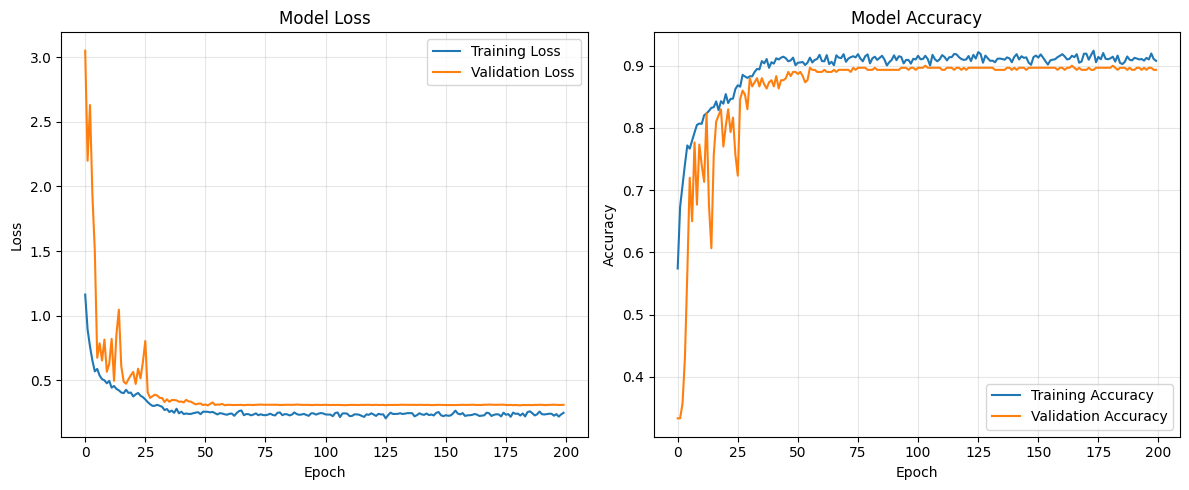

In [23]:
# 8. Plot training history
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Loss plot
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Model Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(history.history['accuracy'], label='Training Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_title('Model Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [24]:
# 9. Evaluate the model
print("\n" + "="*50)
print("FINAL EVALUATION")
print("="*50)

# Training set evaluation
print("\n--- Training Set Evaluation ---")
train_eval = cnn.evaluate(training_set, verbose=0)
print(f"Training Accuracy: {train_eval[1]*100:.2f}%")
print(f"Training Loss: {train_eval[0]:.4f}")

# Validation set evaluation (from test folder)
print("\n--- Test Set Evaluation (Final) ---")
validation_set.reset()  # Reset generator
test_eval = cnn.evaluate(validation_set, verbose=1)
print(f"Test Accuracy: {test_eval[1]*100:.2f}%")
print(f"Test Loss: {test_eval[0]:.4f}")


FINAL EVALUATION

--- Training Set Evaluation ---
Training Accuracy: 94.63%
Training Loss: 0.1620

--- Test Set Evaluation (Final) ---
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8933 - loss: 0.3111 - precision_1: 0.9051 - recall_1: 0.8900
Test Accuracy: 89.33%
Test Loss: 0.3111


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step
Classes: ['Fire', 'Neutral', 'Smoke']

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Fire       0.93      0.90      0.91       100
     Neutral       0.86      0.91      0.88       100
       Smoke       0.90      0.87      0.88       100

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300



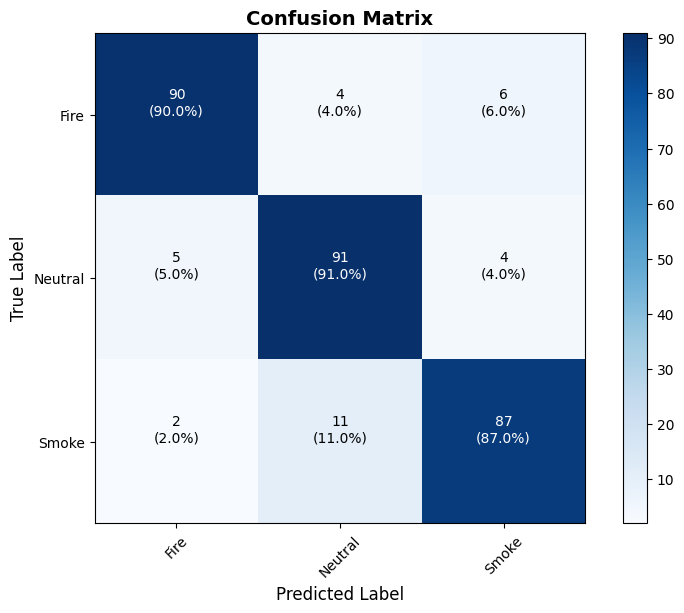

In [25]:
# 10. Generate confusion matrix and classification report
# Reset and get predictions
testing_set.reset()
predictions = cnn.predict(testing_set, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = testing_set.classes

# Get class names in correct order
class_names_list = [class_names[i] for i in sorted(class_names.keys())]
print(f"Classes: {class_names_list}")

# Classification report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names_list))

# Confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Add text annotations
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.1%})',
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=10)

    plt.tight_layout()
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.show()

cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, class_names_list)


SAMPLE PREDICTIONS

Image: image_0.jpg


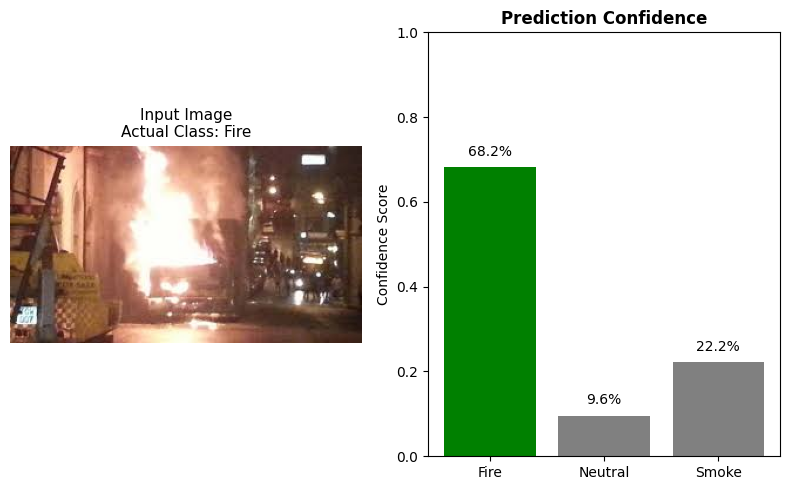


Prediction: Fire
Confidence: 68.24%

Detailed probabilities:
  Fire: 68.24%
  Neutral: 9.56%
  Smoke: 22.20%
----------------------------------------

Image: image_0.jpg


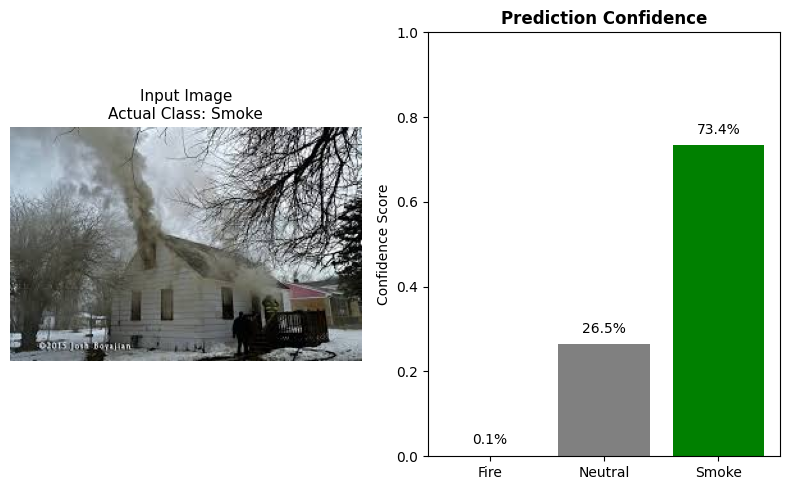


Prediction: Smoke
Confidence: 73.39%

Detailed probabilities:
  Fire: 0.14%
  Neutral: 26.47%
  Smoke: 73.39%
----------------------------------------

Image: image_0.jpg


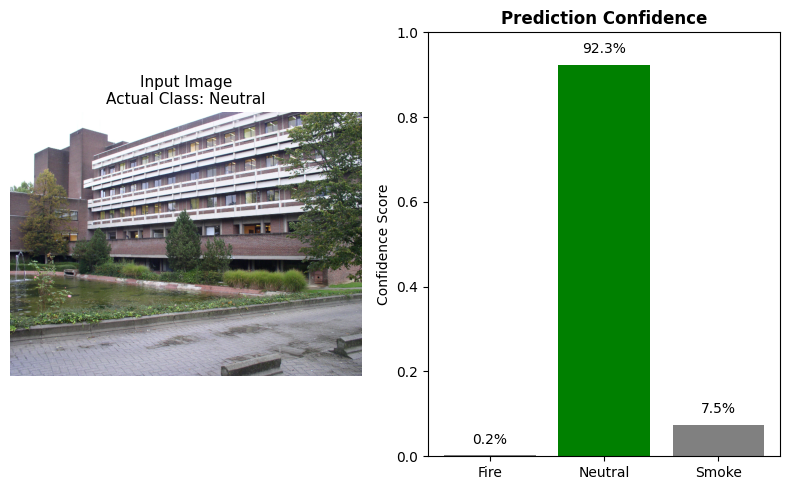


Prediction: Neutral
Confidence: 92.33%

Detailed probabilities:
  Fire: 0.19%
  Neutral: 92.33%
  Smoke: 7.47%
----------------------------------------


In [27]:
# 11. Prediction function with confidence display
def predict_image(image_path, model, class_names_dict, img_size=IMG_SIZE):
    """
    Predict whether an image contains fire, smoke, or neither.
    """
    # Check if file exists
    if not os.path.exists(image_path):
        print(f"Error: Image not found at {image_path}")
        return None, None

    # Load and preprocess image
    img = load_img(image_path, target_size=(img_size, img_size))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Make prediction
    prediction = model.predict(img_array, verbose=0)[0]
    predicted_class_idx = np.argmax(prediction)
    confidence = prediction[predicted_class_idx]

    # Get class name
    class_names_list = [class_names_dict[i] for i in sorted(class_names_dict.keys())]
    predicted_class = class_names_list[predicted_class_idx]

    # Display results
    plt.figure(figsize=(8, 5))

    # Show image
    original_img = cv2.imread(image_path)
    if original_img is not None:
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 2, 1)
        plt.imshow(original_img)
        plt.title(f'Input Image\nActual Class: {os.path.basename(os.path.dirname(image_path))}', fontsize=11)
        plt.axis('off')

    # Show confidence bar chart
    plt.subplot(1, 2, 2)
    colors = ['green' if i == predicted_class_idx else 'gray' for i in range(len(class_names_list))]
    bars = plt.bar(class_names_list, prediction, color=colors)
    plt.title('Prediction Confidence', fontsize=12, fontweight='bold')
    plt.ylabel('Confidence Score')
    plt.ylim(0, 1)

    # Add value labels on bars
    for bar, prob in zip(bars, prediction):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{prob:.1%}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

    print(f"\nPrediction: {predicted_class}")
    print(f"Confidence: {confidence:.2%}")
    print("\nDetailed probabilities:")
    for cls, prob in zip(class_names_list, prediction):
        print(f"  {cls}: {prob:.2%}")

    return predicted_class, confidence

# Test predictions on sample images
print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)

test_images = [
    f'{DATA_DIR}/Test/Fire/image_0.jpg',
    f'{DATA_DIR}/Test/Smoke/image_0.jpg',
    f'{DATA_DIR}/Test/Neutral/image_0.jpg'
]

for img_path in test_images:
    print(f"\nImage: {os.path.basename(img_path)}")
    predict_image(img_path, cnn, class_names)
    print("-" * 40)


Model saved to forest_fire_smoke_detection_model.h5


Model loaded successfully!


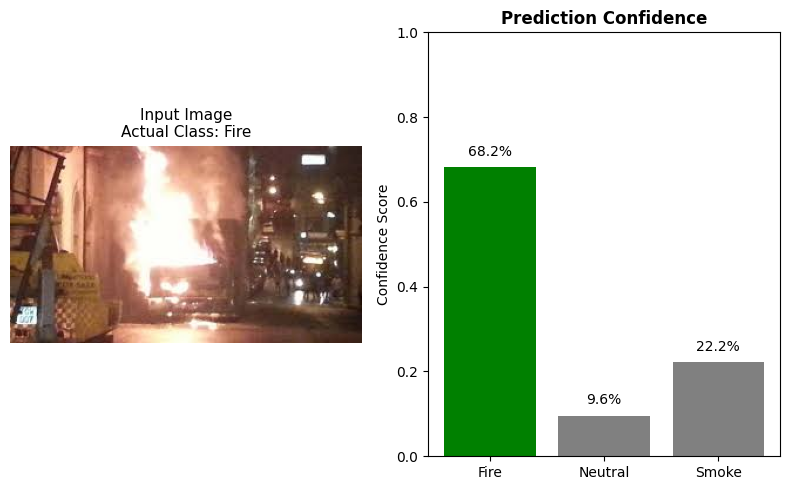


Prediction: Fire
Confidence: 68.24%

Detailed probabilities:
  Fire: 68.24%
  Neutral: 9.56%
  Smoke: 22.20%
Model verification successful! Prediction confidence: 68.24%


In [28]:
# 12. Save the model
model_save_path = 'forest_fire_smoke_detection_model.h5'
cnn.save(model_save_path)
print(f"\nModel saved to {model_save_path}")

# Verify saved model
loaded_model = load_model(model_save_path)
print("Model loaded successfully!")

# Quick verification
test_image_path = test_images[0]
if os.path.exists(test_image_path):
    _, conf = predict_image(test_image_path, loaded_model, class_names)
    print(f"Model verification successful! Prediction confidence: {conf:.2%}")

In [29]:
cnn.save('forest_fire_smoke_detection_model.keras')